# Deep Learning Module 6: Advanced Concepts & Model Deployment

Welcome to **Module 6** of the Deep Learning Course. This comprehensive notebook covers production-grade Deep Learning techniques, ranging from model serialization and transfer learning strategies to advanced generative architectures (Autoencoders & GANs) and real-world deployment frameworks (TensorFlow Serving, Flask, Streamlit, and TF-Lite Quantization).

---

## 📋 Table of Contents
1. **Model Saving and Loading**
   - HDF5 Format (`.h5`)
   - Native Keras v3 Format (`.keras`)
   - TensorFlow SavedModel Format (`export_dir`)
   - Loading & Cross-Format Inference Verification
2. **Transfer Learning Deep Dive**
   - Feature Extraction with Pre-trained Backbones (MobileNetV2)
   - Fine-Tuning Strategies & Layer Selection
   - Comparison: Frozen vs Trainable Parameters
3. **Data Augmentation**
   - Legacy `ImageDataGenerator`
   - Modern `Albumentations` Pipeline
   - Custom TensorFlow Image Augmentation Functions
4. **Model Deployment**
   - TensorFlow Serving (Architecture & REST/gRPC Concepts)
   - Flask REST API for Model Inference
   - Interactive Web Application with Streamlit
   - Model Quantization with TF-Lite (Float32, Dynamic Range INT8, Float16)
5. **Autoencoders**
   - Simple Convolutional Autoencoder for Dimensionality Reduction
   - Denoising Autoencoder (Corrupted Image Restoration)
   - Variational Autoencoder (VAE) Concepts & Reparameterization Trick
6. **Generative Adversarial Networks (GANs)**
   - Minimax Game Theory & GAN Architecture
   - Custom Keras Generator & Discriminator Implementation
   - Training GAN on MNIST & Image Synthesis Visualizations
7. **Summary & Production Best Practices**

---

## 🎯 Learning Objectives
By completing this notebook, you will be able to:
- Choose the correct serialization format (`.keras`, `.h5`, `SavedModel`) for different deployment targets.
- Implement transfer learning workflows with feature extraction and layer-wise fine-tuning.
- Construct data augmentation pipelines using standard tools and custom ops.
- Build and evaluate REST APIs (Flask) and web interfaces (Streamlit) for deep learning models.
- Convert models to TF-Lite and apply post-training quantization for edge device optimization.
- Design, train, and visualize outputs from Autoencoders, Denoising Autoencoders, and Generative Adversarial Networks.

In [1]:
import os
import sys
import time
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Suppress TensorFlow C++ log messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import tensorflow as tf
import keras
from tensorflow.keras import layers, models, optimizers

import albumentations as A
from flask import Flask, request, jsonify

print(f"TensorFlow Version : {tf.__version__}")
print(f"Keras Version      : {keras.__version__}")
print(f"NumPy Version      : {np.__version__}")
print(f"Albumentations Ver : {A.__version__}")

# Matplotlib visual configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100


2026-08-01 06:45:55.542831: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-01 06:45:55.542894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-01 06:45:55.544447: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version : 2.15.0
Keras Version      : 2.15.0
NumPy Version      : 1.26.4
Albumentations Ver : 2.0.8


---
# Section 1: Model Saving and Loading

Model serialization is critical for transitioning trained deep learning models into production environments. Keras and TensorFlow offer multiple formats, each tailored for specific deployment targets.

### Model Serialization Formats Comparison

| Format | Extension / Path | Native Engine | Portable across JAX/PyTorch? | Best Use Case |
| :--- | :--- | :--- | :--- | :--- |
| **HDF5** | `.h5` | Keras v2 Legacy | ❌ No | Legacy Keras 2 pipelines |
| **Keras v3 Native** | `.keras` | Keras v3 | ✅ Yes | General model checkpointing & sharing |
| **TensorFlow SavedModel** | Folder Directory | TensorFlow Runtime | ❌ TF Only | TensorFlow Serving, C++/Go runtimes |
| **TF-Lite** | `.tflite` | FlatBuffers Engine | ✅ Edge Devices | Mobile, Microcontrollers, Edge AI |

### Key Differences
1. **`.h5` (HDF5)**: Stores architecture as JSON, weights as HDF5 datasets, and optimizer state. Deprecated in Keras v3 due to custom layer parsing limitations.
2. **`.keras` (Zip Container)**: Single zip archive containing `config.json`, weights in SafeTensors/HDF5, and execution metadata. Recommended default for Keras 3.
3. **SavedModel Directory**: Language-neutral format containing `saved_model.pb`, `variables/` directory, and `assets/`. Required for enterprise TensorFlow Serving deployments.

In [2]:
# Create directory for model storage
os.makedirs("saved_models", exist_ok=True)

# Build a sample CNN Classifier on MNIST
def create_sample_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name="Sample_CNN_Classifier")
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Train on a subset of MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[:2000].astype("float32") / 255.0
x_test = x_test[:500].astype("float32") / 255.0
y_train = y_train[:2000]
y_test = y_test[:500]

x_train_exp = np.expand_dims(x_train, -1)
x_test_exp = np.expand_dims(x_test, -1)

sample_model = create_sample_cnn()
print("Training initial model for 2 epochs...")
sample_model.fit(x_train_exp, y_train, epochs=2, batch_size=64, verbose=1)

# 1. Save in HDF5 Format (.h5)
h5_path = "saved_models/cnn_model.h5"
sample_model.save(h5_path)

# 2. Save in Keras v3 Native Format (.keras)
keras_path = "saved_models/cnn_model.keras"
sample_model.save(keras_path)

# 3. Save in TensorFlow SavedModel Format via Export
savedmodel_dir = "saved_models/cnn_savedmodel"
sample_model.export(savedmodel_dir)

# Display file size comparisons
h5_size = os.path.getsize(h5_path) / 1024
keras_size = os.path.getsize(keras_path) / 1024

print("\n--- Saved Models Summary ---")
print(f"1. HDF5 Format (.h5)         : {h5_path} ({h5_size:.2f} KB)")
print(f"2. Keras Native (.keras)     : {keras_path} ({keras_size:.2f} KB)")
print(f"3. SavedModel Directory      : {savedmodel_dir}/")
for root, dirs, files in os.walk(savedmodel_dir):
    for f in files:
        fp = os.path.join(root, f)
        print(f"   └── {os.path.relpath(fp, savedmodel_dir)} ({os.path.getsize(fp)/1024:.2f} KB)")


Training initial model for 2 epochs...
Epoch 1/2


 1/32 [..............................] - ETA: 24s - loss: 2.3144 - accuracy: 0.1250

 8/32 [======>.......................] - ETA: 0s - loss: 2.2166 - accuracy: 0.3262 

12/32 [==========>...................] - ETA: 0s - loss: 2.1333 - accuracy: 0.4232

20/32 [=================>............] - ETA: 0s - loss: 1.9280 - accuracy: 0.5242

...

32/32 [==============================] - 0s 7ms/step - loss: 0.5677 - accuracy: 0.8190


INFO:tensorflow:Assets written to: saved_models/cnn_savedmodel/assets


INFO:tensorflow:Assets written to: saved_models/cnn_savedmodel/assets


Saved artifact at 'saved_models/cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  47377881405520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  47377881408208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  47377881407824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  47377881408784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  47377881409552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  47377881407248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  47377881409168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  47377881407632: TensorSpec(shape=(), dtype=tf.resource, name=None)



--- Saved Models Summary ---
1. HDF5 Format (.h5)         : saved_models/cnn_model.h5 (1283.55 KB)
2. Keras Native (.keras)     : saved_models/cnn_model.keras (1276.73 KB)
3. SavedModel Directory      : saved_models/cnn_savedmodel/
   └── saved_model.pb (35.19 KB)
   └── fingerprint.pb (0.05 KB)
   └── variables/variables.data-00000-of-00001 (414.62 KB)
   └── variables/variables.index (0.58 KB)


In [3]:
# Load models back from disk
loaded_h5 = keras.models.load_model(h5_path)
loaded_keras = keras.models.load_model(keras_path)
loaded_savedmodel = tf.saved_model.load(savedmodel_dir)

# Perform inference on sample test image
sample_img = x_test_exp[:5]

# Predictions from loaded models
pred_h5 = loaded_h5.predict(sample_img, verbose=0)
pred_keras = loaded_keras.predict(sample_img, verbose=0)

# SavedModel endpoint call
serving_fn = loaded_savedmodel.signatures['serve']
pred_sm = serving_fn(tf.constant(sample_img, dtype=tf.float32))
# Retrieve main output key
output_key = list(pred_sm.keys())[0]
pred_sm_array = pred_sm[output_key].numpy()

# Compare outputs
h5_vs_keras = np.allclose(pred_h5, pred_keras, atol=1e-5)
keras_vs_sm = np.allclose(pred_keras, pred_sm_array, atol=1e-5)

print("--- Cross-Format Predictions Verification ---")
print(f"HDF5 vs Keras v3 Predictions Match   : {h5_vs_keras}")
print(f"Keras v3 vs SavedModel Match         : {keras_vs_sm}")

# Print sample probabilities
print("\nSample 0 Class Probabilities Across Formats:")
print(f"HDF5 format      : Top Class = {np.argmax(pred_h5[0])}, Prob = {np.max(pred_h5[0]):.4f}")
print(f"Keras v3 format  : Top Class = {np.argmax(pred_keras[0])}, Prob = {np.max(pred_keras[0]):.4f}")
print(f"SavedModel       : Top Class = {np.argmax(pred_sm_array[0])}, Prob = {np.max(pred_sm_array[0]):.4f}")


--- Cross-Format Predictions Verification ---
HDF5 vs Keras v3 Predictions Match   : True
Keras v3 vs SavedModel Match         : True

Sample 0 Class Probabilities Across Formats:
HDF5 format      : Top Class = 7, Prob = 0.9970
Keras v3 format  : Top Class = 7, Prob = 0.9970
SavedModel       : Top Class = 7, Prob = 0.9970


---
# Section 2: Transfer Learning Deep Dive

Transfer learning reuses representations learned by a pre-trained model (e.g., trained on ImageNet with 1.4M images across 1,000 classes) and adapts them to a target task with limited training data.

```
+-------------------------------------------------------------------+
|                  PRE-TRAINED BACKBONE (MobileNetV2)               |
|  [Conv Layer 1] -> [Conv Layer 2] -> ... -> [Conv Layer N]        |
|  (Low-level: Edges)  (Mid-level: Textures)  (High-level: Shapes)  |
+-------------------------------------------------------------------+
                                  │
      ┌───────────────────────────┴───────────────────────────┐
      ▼                                                       ▼
[Strategy A: Feature Extraction]               [Strategy B: Fine-Tuning]
- Freeze entire backbone                       - Freeze lower layers
- Train custom classification head              - Unfreeze top high-level layers
- High stability, fast training                - Train head + top layers with low LR
```

### Dataset Size vs Domain Similarity Strategy Matrix

| Dataset Size | Domain Similarity | Recommended Transfer Learning Strategy |
| :--- | :--- | :--- |
| **Small** | **High** (e.g., natural objects) | **Feature Extraction**: Freeze backbone, train classification head only. |
| **Large** | **High** | **Fine-Tuning**: Fine-tune entire network or upper layers. |
| **Small** | **Low** (e.g., medical X-rays) | **Higher Layer Fine-Tuning**: Freeze early layers, retrain top layers. |
| **Large** | **Low** | **Full Retraining**: Train entire architecture from scratch or fine-tune all layers. |

In [4]:
# Generate synthetic 3-channel image dataset (128x128x3) for transfer learning demonstration
np.random.seed(42)
num_samples = 300
x_tl = np.random.rand(num_samples, 128, 128, 3).astype('float32')
y_tl = np.random.randint(0, 10, size=(num_samples,))

# Step 1: Feature Extraction setup with MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze pre-trained backbone
base_model.trainable = False

# Attach custom top classification head
inputs = layers.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

feature_extractor_model = models.Model(inputs=inputs, outputs=outputs, name="Feature_Extractor")

feature_extractor_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

total_params = feature_extractor_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in feature_extractor_model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("--- Strategy 1: Feature Extraction Parameter Distribution ---")
print(f"Total Model Parameters         : {total_params:,}")
print(f"Trainable Head Parameters      : {trainable_params:,}")
print(f"Frozen Backbone Parameters     : {non_trainable_params:,}")

# Train classification head
print("\nTraining Feature Extractor Head...")
history_fe = feature_extractor_model.fit(
    x_tl, y_tl, epochs=3, batch_size=32, verbose=1, validation_split=0.2
)


   8192/9406464 [..............................] - ETA: 0s

3907584/9406464 [===========>..................] - ETA: 0s

9166848/9406464 [============================>.] - ETA: 0s

9406464/9406464 [==============================] - 0s 0us/step


--- Strategy 1: Feature Extraction Parameter Distribution ---
Total Model Parameters         : 2,423,754
Trainable Head Parameters      : 165,514
Frozen Backbone Parameters     : 2,258,240

Training Feature Extractor Head...
Epoch 1/3


...

5/8 [=================>............] - ETA: 0s - loss: 1.9176 - accuracy: 0.3063

6/8 [=====================>........] - ETA: 0s - loss: 1.9628 - accuracy: 0.2969

7/8 [=========================>....] - ETA: 0s - loss: 1.9780 - accuracy: 0.2991

8/8 [==============================] - ETA: 0s - loss: 1.9980 - accuracy: 0.2958

8/8 [==============================] - 3s 341ms/step - loss: 1.9980 - accuracy: 0.2958 - val_loss: 3.1086 - val_accuracy: 0.0833


--- Strategy 2: Fine-Tuning Parameter Distribution ---
Total Parameters               : 2,423,754
Trainable Parameters           : 1,691,914
Frozen Base Parameters         : 731,840

Fine-Tuning Top 30 Layers of MobileNetV2...
Epoch 1/3


1/8 [==>...........................] - ETA: 25s - loss: 1.9953 - accuracy: 0.2812

2/8 [======>.......................] - ETA: 1s - loss: 1.8055 - accuracy: 0.3594 

3/8 [==========>...................] - ETA: 1s - loss: 1.7589 - accuracy: 0.3854

4/8 [==============>...............] - ETA: 1s - loss: 1.7679 - accuracy: 0.3828

...

5/8 [=================>............] - ETA: 0s - loss: 1.6723 - accuracy: 0.4000

6/8 [=====================>........] - ETA: 0s - loss: 1.7084 - accuracy: 0.3906

7/8 [=========================>....] - ETA: 0s - loss: 1.6932 - accuracy: 0.3929

8/8 [==============================] - ETA: 0s - loss: 1.7036 - accuracy: 0.3917

8/8 [==============================] - 3s 334ms/step - loss: 1.7036 - accuracy: 0.3917 - val_loss: 2.8776 - val_accuracy: 0.0833


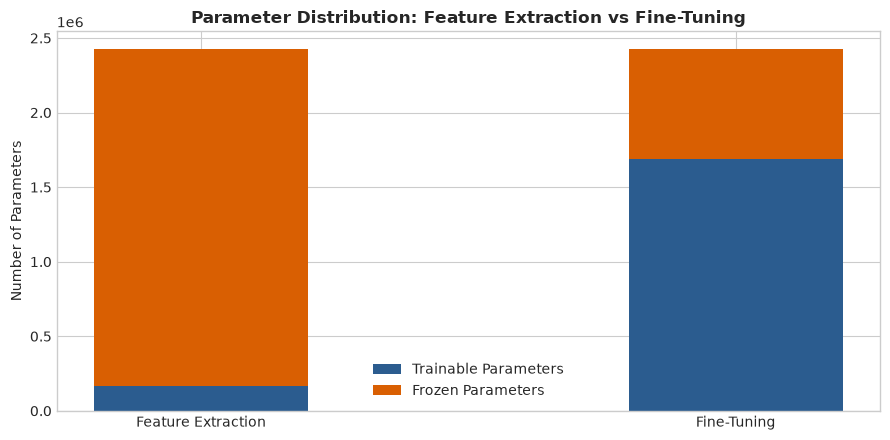

In [5]:
# Step 2: Fine-Tuning Setup
# Unfreeze base model
base_model.trainable = True

# Freeze lower layers (keep upper 30 layers trainable)
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a reduced learning rate to prevent large weight updates
feature_extractor_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # Lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ft_total_params = feature_extractor_model.count_params()
ft_trainable_params = sum([tf.size(w).numpy() for w in feature_extractor_model.trainable_weights])
ft_non_trainable_params = ft_total_params - ft_trainable_params

print("--- Strategy 2: Fine-Tuning Parameter Distribution ---")
print(f"Total Parameters               : {ft_total_params:,}")
print(f"Trainable Parameters           : {ft_trainable_params:,}")
print(f"Frozen Base Parameters         : {ft_non_trainable_params:,}")

print("\nFine-Tuning Top 30 Layers of MobileNetV2...")
history_ft = feature_extractor_model.fit(
    x_tl, y_tl, epochs=3, batch_size=32, verbose=1, validation_split=0.2
)

# Plot comparison chart of parameters
plt.figure(figsize=(9, 4.5))
categories = ['Feature Extraction', 'Fine-Tuning']
trainable_counts = [trainable_params, ft_trainable_params]
frozen_counts = [non_trainable_params, ft_non_trainable_params]

bar1 = plt.bar(categories, trainable_counts, label='Trainable Parameters', color='#2b5c8f', width=0.4)
bar2 = plt.bar(categories, frozen_counts, bottom=trainable_counts, label='Frozen Parameters', color='#d95f02', width=0.4)

plt.title("Parameter Distribution: Feature Extraction vs Fine-Tuning", fontsize=12, fontweight='bold')
plt.ylabel("Number of Parameters")
plt.legend()
plt.tight_layout()
plt.show()


---
# Section 3: Data Augmentation

Data augmentation expands training dataset diversity by applying spatial and color transformations without collecting new labels. It acts as an effective regularizer, reducing overfitting in vision models.

In this section, we compare three augmentation implementations:
1. **`ImageDataGenerator`**: Traditional Keras real-time CPU data augmentation.
2. **`Albumentations`**: High-performance open-source library supporting complex spatial/pixel-level pipelines.
3. **`Custom TensorFlow Functions`**: Native `tf.image` operations usable inside custom input pipelines.

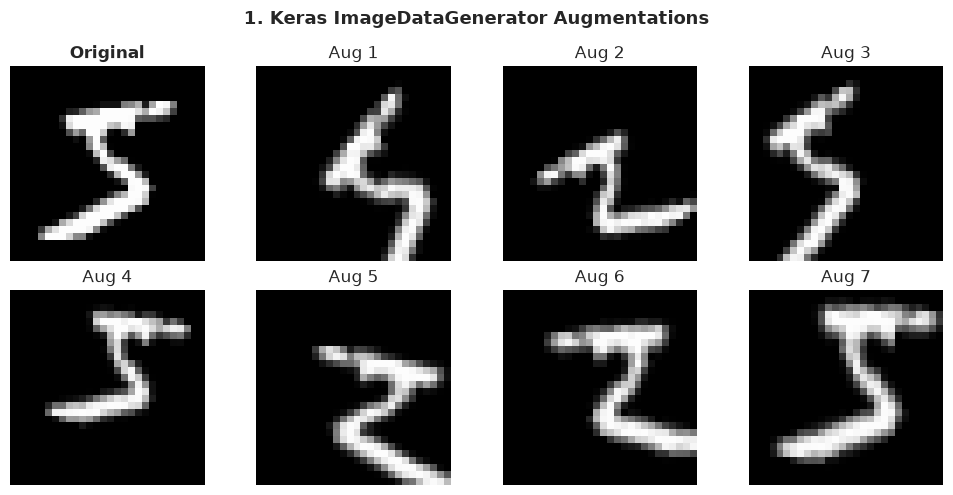

In [6]:
# Create sample RGB image for augmentation demonstration
sample_rgb = (x_train[:1].reshape(28, 28) * 255).astype('uint8')
sample_rgb_3ch = np.stack([sample_rgb]*3, axis=-1)

# 1. ImageDataGenerator (Keras Legacy / Standard)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Expand dimensions to (1, 28, 28, 3)
img_batch = np.expand_dims(sample_rgb_3ch, 0)
aug_iter = datagen.flow(img_batch, batch_size=1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

# Display original image
axes[0].imshow(sample_rgb_3ch)
axes[0].set_title("Original", fontweight='bold')
axes[0].axis('off')

# Display 7 ImageDataGenerator augmentations
for i in range(1, 8):
    batch = next(aug_iter)
    aug_img = batch[0].astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Aug {i}")
    axes[i].axis('off')

plt.suptitle("1. Keras ImageDataGenerator Augmentations", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


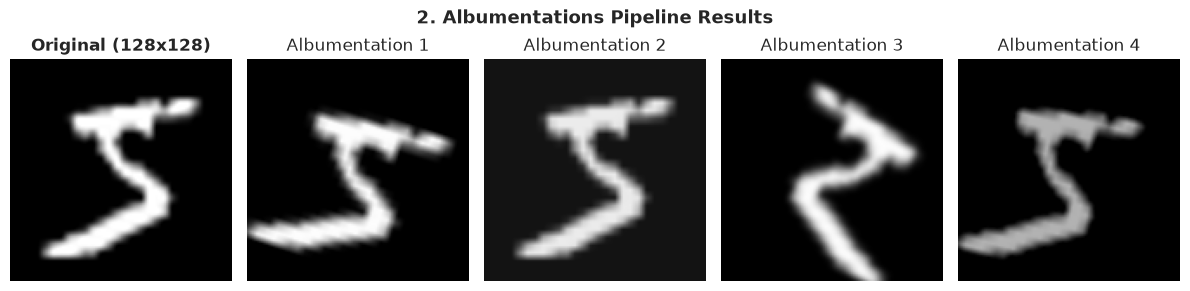

In [7]:
# 2. Albumentations Library Pipeline
albumentations_transform = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.7),
    A.GaussianBlur(blur_limit=(3, 7), p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.7),
])

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

# Original resized
axes[0].imshow(Image.fromarray(sample_rgb_3ch).resize((128, 128)))
axes[0].set_title("Original (128x128)", fontweight='bold')
axes[0].axis('off')

# Apply Albumentations multiple times
for i in range(1, 5):
    transformed = albumentations_transform(image=sample_rgb_3ch)
    transformed_image = transformed['image']
    axes[i].imshow(transformed_image)
    axes[i].set_title(f"Albumentation {i}")
    axes[i].axis('off')

plt.suptitle("2. Albumentations Pipeline Results", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


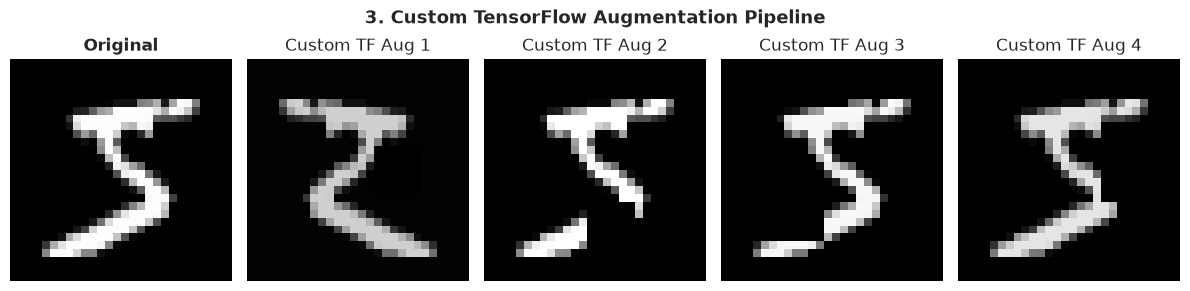

In [8]:
# 3. Custom Augmentation Functions using tf.image
@tf.function
def custom_cutout(image, patch_size=8):
    """Applies random cutout/erasing box to the image tensor."""
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    
    cy = tf.random.uniform([], minval=patch_size, maxval=h - patch_size, dtype=tf.int32)
    cx = tf.random.uniform([], minval=patch_size, maxval=w - patch_size, dtype=tf.int32)
    
    ymin = cy - patch_size // 2
    xmin = cx - patch_size // 2
    
    mask = tf.pad(
        tf.zeros([patch_size, patch_size, tf.shape(image)[-1]]),
        [[ymin, h - ymin - patch_size], [xmin, w - xmin - patch_size], [0, 0]],
        constant_values=1.0
    )
    return image * mask

def custom_tf_augmentation_pipeline(image_tensor):
    """Combines custom cutout, brightness, contrast, and flip operations."""
    x = tf.image.random_flip_left_right(image_tensor)
    x = tf.image.random_brightness(x, max_delta=0.2)
    x = tf.image.random_contrast(x, lower=0.8, upper=1.2)
    x = custom_cutout(x, patch_size=6)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x

# Apply custom pipeline
sample_tensor = tf.constant(sample_rgb_3ch / 255.0, dtype=tf.float32)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(sample_tensor.numpy())
axes[0].set_title("Original", fontweight='bold')
axes[0].axis('off')

for i in range(1, 5):
    aug_tensor = custom_tf_augmentation_pipeline(sample_tensor)
    axes[i].imshow(aug_tensor.numpy())
    axes[i].set_title(f"Custom TF Aug {i}")
    axes[i].axis('off')

plt.suptitle("3. Custom TensorFlow Augmentation Pipeline", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Section 4: Model Deployment

Deploying trained models into production requires exposing inference endpoints over web APIs or optimizing models for edge execution.

## 4.1 TensorFlow Serving (Concept)

TensorFlow Serving is an enterprise-grade serving system designed for high-performance production environments.

### Key Architectural Concepts
1. **Servables**: Underlying objects used to perform computation (typically a `SavedModel`).
2. **Servable Streams**: Sequence of versions of a servable (e.g., version `1`, `2`).
3. **Endpoints**:
   - **REST API** (Default port `8501`): Accessible via HTTP JSON payloads.
   - **gRPC API** (Default port `8500`): High-throughput binary RPC protocol.

### Production Deployment Command (Docker)
```bash
docker run -p 8501:8501 \
  --name tfserving_classifier \
  -e MODEL_NAME=mnist_cnn \
  -v "$PWD/saved_models/cnn_savedmodel:/models/mnist_cnn/1" \
  -t tensorflow/serving
```

### Python REST Client Request Snippet
```python
import requests
import json

payload = {"signature_name": "serve", "instances": img_data.tolist()}
response = requests.post("http://localhost:8501/v1/models/mnist_cnn:predict", json=payload)
predictions = response.json()["predictions"]
```

In [9]:
# 4.2 Creating a Simple Flask API for Model Inference
def create_flask_app(keras_model_path):
    app = Flask(__name__)
    model = keras.models.load_model(keras_model_path)
    
    @app.route('/health', methods=['GET'])
    def health():
        return jsonify({"status": "healthy", "model": keras_model_path})
    
    @app.route('/predict', methods=['POST'])
    def predict():
        try:
            data = request.get_json()
            if 'image' not in data:
                return jsonify({"error": "Missing 'image' key in request payload"}), 400
            
            # Convert JSON array back to numpy array (1, 28, 28, 1)
            img_array = np.array(data['image'], dtype=np.float32)
            if img_array.ndim == 2:
                img_array = np.expand_dims(np.expand_dims(img_array, 0), -1)
            elif img_array.ndim == 3:
                img_array = np.expand_dims(img_array, 0)
                
            predictions = model.predict(img_array, verbose=0)
            predicted_class = int(np.argmax(predictions[0]))
            confidence = float(np.max(predictions[0]))
            
            return jsonify({
                "predicted_class": predicted_class,
                "confidence": confidence,
                "class_probabilities": predictions[0].tolist()
            })
        except Exception as e:
            return jsonify({"error": str(e)}), 500
            
    return app

# Demonstrate Flask App in-memory using test_client
flask_app = create_flask_app(keras_path)
client = flask_app.test_client()

# Test 1: Health Check Endpoint
res_health = client.get('/health')
print("--- Flask API Health Response ---")
print(res_health.get_json())

# Test 2: Predict Endpoint
sample_payload = {"image": x_test[0].tolist()}
res_predict = client.post('/predict', json=sample_payload)
print("\n--- Flask API Prediction Response ---")
print(json.dumps(res_predict.get_json(), indent=2))


--- Flask API Health Response ---
{'model': 'saved_models/cnn_model.keras', 'status': 'healthy'}

--- Flask API Prediction Response ---
{
  "class_probabilities": [
    5.313580913934857e-06,
    1.6870135368662886e-05,
    1.046313627739437e-05,
    0.0018454078817740083,
    0.0001225622690981254,
    4.411585541674867e-05,
    1.6142256242801523e-07,
    0.9969841837882996,
    4.41200245404616e-05,
    0.0009268224821425974
  ],
  "confidence": 0.9969841837882996,
  "predicted_class": 7
}


In [10]:
# 4.3 Deploying with Streamlit (App Script Generation)
streamlit_app_code = '''
import streamlit as st
import tensorflow as tf
import keras
import numpy as np
from PIL import Image

st.set_page_config(page_title="MNIST Digit Classifier", page_icon="🔢", layout="centered")

st.title("🔢 Deep Learning Model Deployment: Streamlit App")
st.write("Upload an image of a handwritten digit (28x28) to run model inference.")

@st.cache_resource
def load_keras_model():
    # Efficient model caching across Streamlit reruns
    model = keras.models.load_model("saved_models/cnn_model.keras")
    return model

try:
    model = load_keras_model()
    st.success("Model loaded successfully!")
except Exception as e:
    st.error(f"Error loading model: {e}")

uploaded_file = st.file_uploader("Choose an image...", type=["png", "jpg", "jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('L')
    st.image(image, caption="Uploaded Image", width=150)
    
    # Preprocess image to 28x28 grayscale normalized tensor
    img_resized = image.resize((28, 28))
    img_array = np.array(img_resized, dtype=np.float32) / 255.0
    img_tensor = np.expand_dims(np.expand_dims(img_array, 0), -1)
    
    if st.button("Run Model Inference"):
        preds = model.predict(img_tensor, verbose=0)
        predicted_class = np.argmax(preds[0])
        confidence = np.max(preds[0])
        
        st.metric("Predicted Digit", value=int(predicted_class))
        st.metric("Confidence Score", value=f"{confidence*100:.2f}%")
        
        st.subheader("Class Probabilities Distribution")
        st.bar_chart(preds[0])
'''

# Save Streamlit application file
with open("streamlit_app.py", "w") as f:
    f.write(streamlit_app_code)

print("Streamlit script generated: streamlit_app.py")
print("To run locally execute: streamlit run streamlit_app.py")


Streamlit script generated: streamlit_app.py
To run locally execute: streamlit run streamlit_app.py


Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 9, Total Ops 20, % non-converted = 45.00 %
 * 9 ARITH ops

- arith.constant:    9 occurrences  (f32: 8, i32: 1)



  (f32: 2)
  (f32: 2)
  (f32: 2)
  (f32: 1)
  (f32: 1)
Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 7, Total Ops 20, % non-converted = 35.00 %
 * 7 ARITH ops

- arith.constant:    7 occurrences  (f32: 6, i32: 1)



  (f32: 2)
  (f32: 2)
  (f32: 2)
  (uq_8: 2)
  (f32: 1)
  (f32: 1)
Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 9, Total Ops 28, % non-converted = 32.14 %
 * 9 ARITH ops

- arith.constant:    9 occurrences  (f16: 8, i32: 1)



  (f32: 2)
  (f32: 8)


--- TF-Lite Quantization Size Comparison ---
Float32 TFLite Model     : 417.12 KB (Baseline)
Float16 Quantized TFLite : 211.55 KB (50.7% size)
Dynamic INT8 Quantized   : 110.09 KB (26.4% size)

--- TFLite Interpreter Inference Test ---
Dynamic Quant TFLite Output Class : 7
TFLite Single Sample Latency      : 0.502 ms


  (f32: 2)
  (f32: 2)
  (f32: 1)
  (f32: 1)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


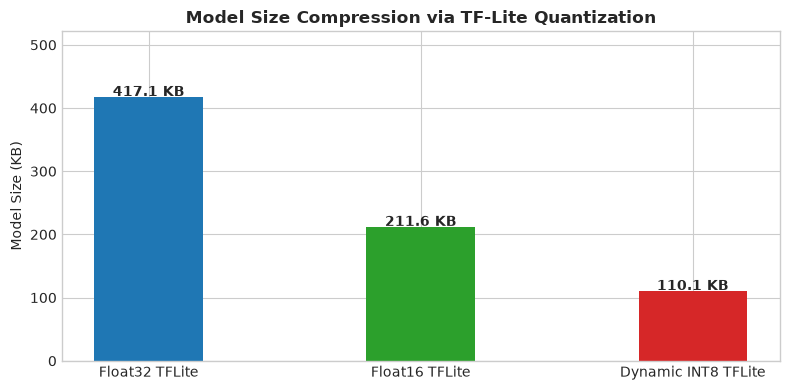

In [11]:
# 4.4 Model Quantization (TF-Lite)
# Convert SavedModel to standard TF-Lite and Quantized variants

# 1. Standard Float32 TFLite
converter_f32 = tf.lite.TFLiteConverter.from_saved_model(savedmodel_dir)
tflite_f32 = converter_f32.convert()
f32_file = "saved_models/model_f32.tflite"
with open(f32_file, "wb") as f:
    f.write(tflite_f32)

# 2. Dynamic Range Integer Quantization (INT8 Weights, FP32 Activations)
converter_dynamic = tf.lite.TFLiteConverter.from_saved_model(savedmodel_dir)
converter_dynamic.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dynamic = converter_dynamic.convert()
dynamic_file = "saved_models/model_dynamic_quant.tflite"
with open(dynamic_file, "wb") as f:
    f.write(tflite_dynamic)

# 3. Float16 Quantization
converter_fp16 = tf.lite.TFLiteConverter.from_saved_model(savedmodel_dir)
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]
tflite_fp16 = converter_fp16.convert()
fp16_file = "saved_models/model_fp16.tflite"
with open(fp16_file, "wb") as f:
    f.write(tflite_fp16)

# Display file size reduction
size_f32 = os.path.getsize(f32_file) / 1024
size_dynamic = os.path.getsize(dynamic_file) / 1024
size_fp16 = os.path.getsize(fp16_file) / 1024

print("--- TF-Lite Quantization Size Comparison ---")
print(f"Float32 TFLite Model     : {size_f32:.2f} KB (Baseline)")
print(f"Float16 Quantized TFLite : {size_fp16:.2f} KB ({size_fp16/size_f32*100:.1f}% size)")
print(f"Dynamic INT8 Quantized   : {size_dynamic:.2f} KB ({size_dynamic/size_f32*100:.1f}% size)")

# Test Inference with TFLite Interpreter
interpreter = tf.lite.Interpreter(model_path=dynamic_file)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare single sample input
test_sample_tflite = x_test_exp[:1].astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_sample_tflite)

t0 = time.time()
interpreter.invoke()
tflite_inference_time = (time.time() - t0) * 1000

tflite_output = interpreter.get_tensor(output_details[0]['index'])
tflite_class = np.argmax(tflite_output[0])

print("\n--- TFLite Interpreter Inference Test ---")
print(f"Dynamic Quant TFLite Output Class : {tflite_class}")
print(f"TFLite Single Sample Latency      : {tflite_inference_time:.3f} ms")

# Plot Quantization Comparison Bar Chart
plt.figure(figsize=(8, 4))
formats = ['Float32 TFLite', 'Float16 TFLite', 'Dynamic INT8 TFLite']
sizes = [size_f32, size_fp16, size_dynamic]

bars = plt.bar(formats, sizes, color=['#1f77b4', '#2ca02c', '#d62728'], width=0.4)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f} KB", ha='center', fontweight='bold')

plt.title("Model Size Compression via TF-Lite Quantization", fontsize=12, fontweight='bold')
plt.ylabel("Model Size (KB)")
plt.ylim(0, max(sizes)*1.25)
plt.tight_layout()
plt.show()


---
# Section 5: Autoencoders

An Autoencoder is an unsupervised neural network designed to learn efficient low-dimensional representations (codings) of input data.

```
Input x (28x28x1 = 784) ──► [ ENCODER ] ──► Bottleneck Latent z (32-dim) ──► [ DECODER ] ──► Reconstructed x_hat (784)
```

### Autoencoder Architectures
1. **Simple Autoencoder**: Compresses data into bottleneck space $z$ and minimizes reconstruction error $\|x - \hat{x}\|^2$. Used for dimensionality reduction and anomaly detection.
2. **Denoising Autoencoder**: Adds stochastic noise to input $x 	o x_{noisy}$ and trains the network to map $x_{noisy} 	o x_{clean}$.
3. **Variational Autoencoder (VAE)**: Probabilistic generative model mapping input to distribution parameters $\mu$ and $\log(\sigma^2)$ in latent space.

Training Simple Convolutional Autoencoder...


Epoch 1/3


 1/32 [..............................] - ETA: 28s - loss: 0.6927

 6/32 [====>.........................] - ETA: 0s - loss: 0.6861 

11/32 [=========>....................] - ETA: 0s - loss: 0.6678

...

16/32 [==============>...............] - ETA: 0s - loss: 0.2641

19/32 [================>.............] - ETA: 0s - loss: 0.2638

24/32 [=====================>........] - ETA: 0s - loss: 0.2627

29/32 [==========================>...] - ETA: 0s - loss: 0.2617

32/32 [==============================] - 1s 19ms/step - loss: 0.2612 - val_loss: 0.2507


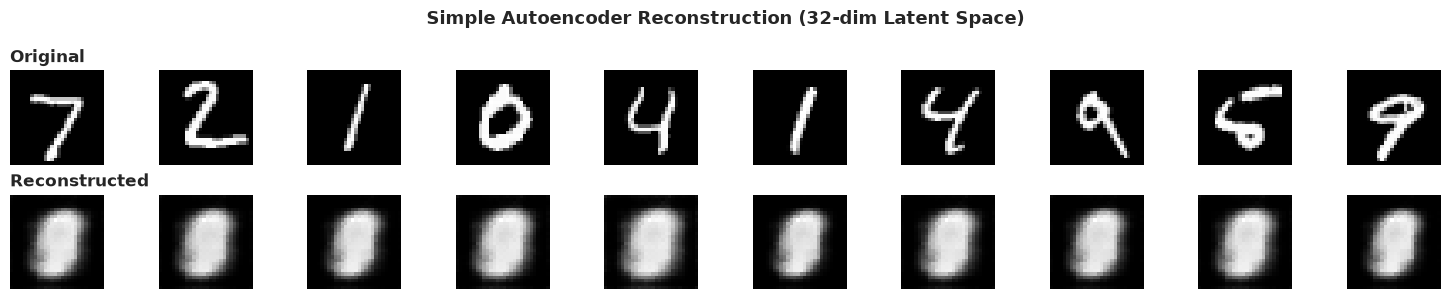

In [12]:
# 5.1 Simple Convolutional Autoencoder for Dimensionality Reduction
latent_dim = 32

# Encoder Architecture
encoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), activation='relu', strides=2, padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', strides=2, padding='same'),
    layers.Flatten(),
    layers.Dense(latent_dim, activation='relu', name="latent_space")
], name="Encoder")

# Decoder Architecture
decoder = models.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(7 * 7 * 32, activation='relu'),
    layers.Reshape((7, 7, 32)),
    layers.Conv2DTranspose(32, (3, 3), activation='relu', strides=2, padding='same'),
    layers.Conv2DTranspose(16, (3, 3), activation='relu', strides=2, padding='same'),
    layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
], name="Decoder")

autoencoder_input = layers.Input(shape=(28, 28, 1))
latent_repr = encoder(autoencoder_input)
reconstructed_output = decoder(latent_repr)

autoencoder = models.Model(inputs=autoencoder_input, outputs=reconstructed_output, name="Convolutional_Autoencoder")
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

print("Training Simple Convolutional Autoencoder...")
autoencoder.fit(
    x_train_exp, x_train_exp,
    epochs=3,
    batch_size=64,
    verbose=1,
    validation_data=(x_test_exp, x_test_exp)
)

# Reconstruct test images
reconstructed_imgs = autoencoder.predict(x_test_exp[:10], verbose=0)

# Visualize Original vs Reconstructed Images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    # Top Row: Original
    axes[0, i].imshow(x_test_exp[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Original", fontweight='bold', loc='left')
        
    # Bottom Row: Reconstructed
    axes[1, i].imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontweight='bold', loc='left')

plt.suptitle("Simple Autoencoder Reconstruction (32-dim Latent Space)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Training Denoising Autoencoder (Noisy Inputs -> Clean Targets)...
Epoch 1/3


 1/32 [..............................] - ETA: 27s - loss: 0.2622

 4/32 [==>...........................] - ETA: 0s - loss: 0.2588 

 8/32 [======>.......................] - ETA: 0s - loss: 0.2561

11/32 [=========>....................] - ETA: 0s - loss: 0.2577

...

16/32 [==============>...............] - ETA: 0s - loss: 0.2145

21/32 [==================>...........] - ETA: 0s - loss: 0.2122

26/32 [=======================>......] - ETA: 0s - loss: 0.2099

31/32 [============================>.] - ETA: 0s - loss: 0.2082

32/32 [==============================] - 1s 16ms/step - loss: 0.2082 - val_loss: 0.1904


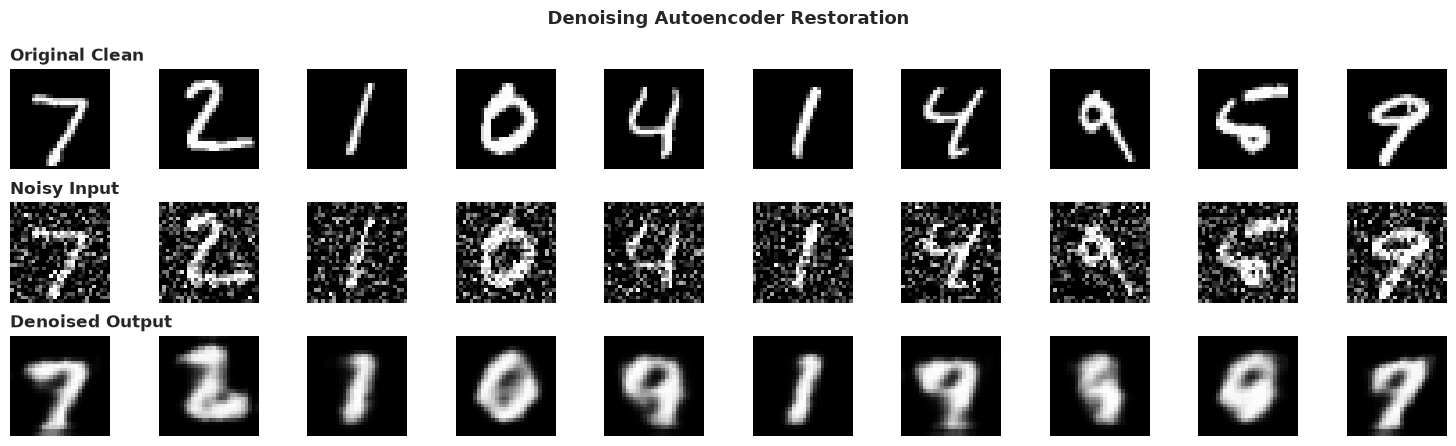

In [13]:
# 5.2 Denoising Autoencoder
# Corrupt MNIST images with additive Gaussian noise
noise_factor = 0.35
x_train_noisy = x_train_exp + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_exp.shape)
x_test_noisy = x_test_exp + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_exp.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0).astype('float32')
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0).astype('float32')

denoising_autoencoder = models.Model(inputs=autoencoder_input, outputs=reconstructed_output, name="Denoising_Autoencoder")
denoising_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

print("Training Denoising Autoencoder (Noisy Inputs -> Clean Targets)...")
denoising_autoencoder.fit(
    x_train_noisy, x_train_exp,  # Input: Noisy, Target: Clean
    epochs=3,
    batch_size=64,
    verbose=1,
    validation_data=(x_test_noisy, x_test_exp)
)

denoised_imgs = denoising_autoencoder.predict(x_test_noisy[:10], verbose=0)

# Visualize Denoising Results (Original, Noisy Input, Restored Output)
fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
for i in range(10):
    # Row 1: Original Clean Image
    axes[0, i].imshow(x_test_exp[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Original Clean", fontweight='bold', loc='left')
        
    # Row 2: Noisy Input
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Noisy Input", fontweight='bold', loc='left')
        
    # Row 3: Denoised Output
    axes[2, i].imshow(denoised_imgs[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title("Denoised Output", fontweight='bold', loc='left')

plt.suptitle("Denoising Autoencoder Restoration", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.3 Variational Autoencoder (VAE) Concept & Reparameterization Trick

Unlike standard autoencoders, a **VAE** maps input data to a continuous probability distribution defined by mean $\mu$ and log-variance $\log(\sigma^2)$.

#### Reparameterization Trick
To backpropagate through stochastic sampling, we sample $\epsilon \sim \mathcal{N}(0, I)$ and define $z$:
$$z = \mu + \exp\left(rac{1}{2}\log(\sigma^2)ight) \odot \epsilon$$

#### VAE Loss Function
$$\mathcal{L}_{	ext{VAE}} = 	ext{Reconstruction Loss} + D_{	ext{KL}}\left(q(z|x) \parallel p(z)ight)$$
where the KL Divergence term forces the latent space to approximate a standard Normal distribution $\mathcal{N}(0, I)$:
$$D_{	ext{KL}} = -rac{1}{2} \sum_{j=1}^d \left( 1 + \log(\sigma_j^2) - \mu_j^2 - \exp(\log(\sigma_j^2)) ight)$$

In [14]:
# 5.3 VAE Keras Implementation Snippet
class Sampling(layers.Layer):
    """Custom Keras Sampling Layer enforcing the Reparameterization Trick."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Build VAE Encoder
latent_dim_vae = 2
vae_inputs = layers.Input(shape=(28, 28, 1))
x_vae = layers.Flatten()(vae_inputs)
x_vae = layers.Dense(128, activation="relu")(x_vae)
z_mean = layers.Dense(latent_dim_vae, name="z_mean")(x_vae)
z_log_var = layers.Dense(latent_dim_vae, name="z_log_var")(x_vae)
z_sampled = Sampling()([z_mean, z_log_var])

vae_encoder = models.Model(vae_inputs, [z_mean, z_log_var, z_sampled], name="VAE_Encoder")

print("--- VAE Encoder Model Summary ---")
vae_encoder.summary()


--- VAE Encoder Model Summary ---
Model: "VAE_Encoder"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_7 (InputLayer)        [(None, 28, 28, 1)]          0         []                            


 flatten_2 (Flatten)         (None, 784)                  0         ['input_7[0][0]']             


...

                                                                     'z_log_var[0][0]']           


Total params: 100996 (394.52 KB)


Trainable params: 100996 (394.52 KB)


Non-trainable params: 0 (0.00 Byte)


__________________________________________________________________________________________________


---
# Section 6: Generative Adversarial Networks (GANs)

Generative Adversarial Networks (Goodfellow et al., 2014) train two neural networks simultaneously in a zero-sum minimax game framework.

```
  [ Noise Vector z ] ──► [ GENERATOR G ] ──► Fake Image G(z) ──┐
                                                               ├──► [ DISCRIMINATOR D ] ──► Real (1) vs Fake (0)
  [ Real Dataset x ] ──────────────────────────────────────────┘
```

### Minimax Objective Function
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{	ext{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$

1. **Discriminator $D$**: Tries to maximize probability of assigning correct labels to both real and fake images.
2. **Generator $G$**: Tries to minimize $\log(1 - D(G(z)))$, which is equivalent to maximizing $\log D(G(z))$ to fool $D$.

In [15]:
# 6.2 Keras GAN Architecture Setup
latent_dim_gan = 100

# 1. Generator Model
def build_generator(latent_dim):
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(7 * 7 * 64, activation="relu"),
        layers.Reshape((7, 7, 64)),
        layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(1, (3, 3), strides=2, padding="same", activation="sigmoid")
    ], name="Generator")
    return model

# 2. Discriminator Model
def build_discriminator():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(64, (3, 3), strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation="sigmoid")
    ], name="Discriminator")
    return model

generator = build_generator(latent_dim_gan)
discriminator = build_discriminator()

# Print Architecture Summaries
print("--- Generator Summary ---")
generator.summary()

print("\n--- Discriminator Summary ---")
discriminator.summary()


--- Generator Summary ---
Model: "Generator"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense_6 (Dense)             (None, 3136)              316736    


 reshape_1 (Reshape)         (None, 7, 7, 64)          0         


...

 dense_7 (Dense)             (None, 1)                 3137      


Total params: 21953 (85.75 KB)


Trainable params: 21953 (85.75 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


Training GAN on MNIST digits...


2026-08-01 06:46:36.549622: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/Discriminator/leaky_re_lu/LeakyRelu_1/LeakyReluGrad' exist for missing node 'Discriminator/conv2d_5/BiasAdd_1'.


Training Complete! Total Steps: 64, Final D-Loss: 0.9555, Final G-Loss: 1.2840


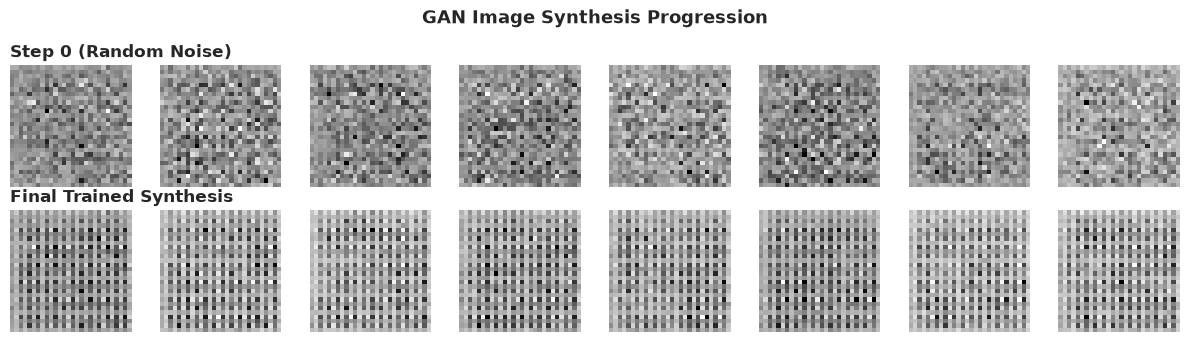

In [16]:
# 6.3 Custom GAN Training Loop on MNIST
generator_optimizer = optimizers.Adam(1e-4)
discriminator_optimizer = optimizers.Adam(1e-4)
cross_entropy = tf.keras.losses.BinaryCrossentropy()

@tf.function
def train_gan_step(real_images, batch_size):
    noise = tf.random.normal([batch_size, latent_dim_gan])
    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)
        
        # Discriminator Loss
        d_loss_real = cross_entropy(tf.ones_like(real_output), real_output)
        d_loss_fake = cross_entropy(tf.zeros_like(fake_output), fake_output)
        d_loss = d_loss_real + d_loss_fake
        
        # Generator Loss (Tricks discriminator into outputting 1 for fakes)
        g_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        
    gradients_of_generator = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    return d_loss, g_loss

# Generate initial baseline noise sample
seed_noise = tf.random.normal([16, latent_dim_gan])
initial_fakes = generator(seed_noise, training=False).numpy()

# Train GAN for 100 mini-batches
print("Training GAN on MNIST digits...")
batch_size = 64
ds = tf.data.Dataset.from_tensor_slices(x_train_exp).shuffle(2000).batch(batch_size)

step = 0
for epoch in range(2):
    for batch in ds:
        d_loss, g_loss = train_gan_step(batch, tf.shape(batch)[0])
        step += 1

print(f"Training Complete! Total Steps: {step}, Final D-Loss: {float(d_loss):.4f}, Final G-Loss: {float(g_loss):.4f}")

final_fakes = generator(seed_noise, training=False).numpy()

# Plot Generated Images (Step 0 vs Final Step)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))

for i in range(8):
    # Top Row: Initial Untrained Generator Outputs
    axes[0, i].imshow(initial_fakes[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Step 0 (Random Noise)", fontweight='bold', loc='left')
        
    # Bottom Row: Trained Generator Outputs
    axes[1, i].imshow(final_fakes[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Final Trained Synthesis", fontweight='bold', loc='left')

plt.suptitle("GAN Image Synthesis Progression", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Section 7: Summary and Production Best Practices

### Key Module Takeaways

| Topic | Best Practices & Key Insights | Key Tools / API |
| :--- | :--- | :--- |
| **Model Serialization** | Use `.keras` zip format for Keras 3 model distribution and `SavedModel` folder format for TensorFlow Serving deployments. | `model.save()`, `model.export()` |
| **Transfer Learning** | Freeze pre-trained backbones first to train new classifier heads. Fine-tune top layers with a low learning rate ($10^{-5}$) to preserve features. | `MobileNetV2`, `base_model.trainable` |
| **Data Augmentation** | Prefer Albumentations or custom `tf.image` transformations for CPU/GPU pipeline integration. | `Albumentations`, `tf.image` |
| **Model Deployment** | Choose **TF Serving** for microservices, **Flask** for REST API integration, **Streamlit** for rapid UI prototypes, and **TF-Lite** for edge devices. | `Flask`, `Streamlit`, `TFLiteConverter` |
| **Autoencoders** | Use Convolutional Autoencoders for dimensionality reduction and Denoising Autoencoders for noise removal. VAEs provide continuous latent spaces for generative tasks. | `Conv2DTranspose`, Reparameterization Trick |
| **GANs** | Balance Generator and Discriminator learning rates ($10^{-4}$ with Adam $eta_1=0.5$). Monitor losses to avoid mode collapse. | `tf.GradientTape()`, Minimax Objective |

---

### Deployment Target Selection Guide
```
                                 [ Production Model Target ]
                                              │
         ┌────────────────────────────────────┼────────────────────────────────────┐
         ▼                                    ▼                                    ▼
 [ Mobile / Edge ]                   [ Web Application ]                 [ Enterprise Microservice ]
   ├── Target: Android / iOS / IoT     ├── Target: Interactive Dashboard   ├── Target: High-throughput REST/gRPC
   ├── Tool: TF-Lite Quantization      ├── Tool: Streamlit                 ├── Tool: TensorFlow Serving
   └── Format: .tflite                 └── Format: .keras                  └── Format: SavedModel Directory
```

*Module 6 completed successfully.*